In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/sf-booking/hotels_test.csv
/kaggle/input/competitions/sf-booking/hotels_train.csv
/kaggle/input/competitions/sf-booking/submission.csv


### Project-3. EDA  Hotels rank
#### Прогнозирование рейтинга отелей имеющихся в базе компании Booking. 

Задача.

Перед нами поставили задау - построить модель, которая предсказывает рейтинг отеля, для понимания на сколько рейтинги отелей совпадают с реальностью. Если предсказания модели сильно отличаются от фактического результата, то, возможно, отель ведёт себя нечестно, и его стоит проверить.



#### Описание имеющихся признаков
* **hotel_address** — адрес отеля;
* **review_date** — дата, когда рецензент разместил соответствующий отзыв;
* **average_score** — средний балл отеля, рассчитанный на основе последнего комментария за последний год;
* **hotel_name** — название отеля;
* **reviewer_nationality** — страна рецензента;
* **negative_review** — отрицательный отзыв, который рецензент дал отелю;
* **review_total_negative_word_counts** — общее количество слов в отрицательном отзыв;
* **positive_review** — положительный отзыв, который рецензент дал отелю;
* **review_total_positive_word_counts** — общее количество слов в положительном отзыве.
* **reviewer_score** — оценка, которую рецензент поставил отелю на основе своего опыта;
* **total_number_of_reviews_reviewer_has_given** — количество отзывов, которые рецензенты дали в прошлом;
* **total_number_of_reviews** — общее количество действительных отзывов об отеле;
* **tags** — теги, которые рецензент дал отелю;
* **days_since_review** — количество дней между датой проверки и датой очистки;
* **additional_number_of_scoring** — есть также некоторые гости, которые просто поставили оценку
  сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.
* **lat** — географическая широта отеля;
* **lng** — географическая долгота отеля.

In [2]:
import pandas as pd

In [3]:
df_hotels_test = pd.read_csv('/kaggle/input/competitions/sf-booking/hotels_test.csv')
df_hotels_train = pd.read_csv('/kaggle/input/competitions/sf-booking/hotels_train.csv')
pred_submission = pd.read_csv('/kaggle/input/competitions/sf-booking/submission.csv')
print(f'Колличество строк и признаков в тестовом датасете: {df_hotels_test.shape}')
print('=================================================================')
print(f'Колличество строк и признаков в тренировочном датасете: {df_hotels_train.shape}')
print('=================================================================')
display(pred_submission.sample(5))

Колличество строк и признаков в тестовом датасете: (128935, 16)
Колличество строк и признаков в тренировочном датасете: (386803, 17)


,reviewer_score,id
43467,6,272110
102008,6,394247
76708,4,419920
73824,1,373765
114965,10,282219


In [4]:
df_hotels_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

#### Для улучшения качества модели объединим данные из "тестового" и "тренировочного" датасетов.

Мы видим что размеры "тестового" и "тренировочного" датасетов разные поэтому проведем небольшие подготовительные работы перед объединением

In [5]:
df_hotels_test['marker'] = 0  # отметим тестовый датасет 0
df_hotels_train['marker'] = 1  # отметим тренировочный датасет 1
# заполним признак 'reviewer_score' нулями, так как в этом DF его нет
df_hotels_test['reviewer_score'] = 0  

In [6]:
# Проверим тренировочный датасет на наличие в нем дубликатов
dupl_columns = list(df_hotels_train.columns)
mask = df_hotels_train.duplicated(subset=dupl_columns)
hotels_duplicates = df_hotels_train[mask]
print(f'Число найденных дубликатов: {hotels_duplicates.shape[0]}')

Число найденных дубликатов: 307


In [7]:
# Удалим дубликаты из тренировочного датасета
df_hotels_train = df_hotels_train.drop_duplicates(subset=dupl_columns)
print(f'Число записей в df df_hotels_train: {df_hotels_train.shape[0]}')

Число записей в df df_hotels_train: 386496


In [8]:
# Объединяем два датасета
df_hotels = pd.concat([df_hotels_test, df_hotels_train], sort = False).reset_index(drop = True)

display(df_hotels.head(3))  # Посмотрим результат
df_hotels.info()  # Посмотрим информацию о рабочем df

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng,marker,reviewer_score
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102,0,0.0
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443,0,0.0
2,Mallorca 251 Eixample 08008 Barcelona Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,2.161520,0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   review_date                                 515431 non-null  object 
 3   average_score                               515431 non-null  float64
 4   hotel_name                                  515431 non-null  object 
 5   reviewer_nationality                        515431 non-null  object 
 6   negative_review                             515431 non-null  object 
 7   review_total_negative_word_counts           515431 non-null  int64  
 8   total_number_of_reviews                     515431 non-null  int64  
 9   positive_review                             515431 non-null  object 
 

In [9]:
print(f'Количество строк и столбцов в df_hotels: {df_hotels.shape}')

Количество строк и столбцов в df_hotels: (515431, 18)


##### В результате мы получили DF у которого пропуски есть только в двух признаках: lat и lng. Остальные признаки заполнены.

### Очистка, создание новых признаков и преобразование

#### В первую очередь разберем два признака "negative_review" и "positive_review"

In [10]:
# Создадим рабочий DF, чтобы данные вводного DF не изменялись.
hotels_df = df_hotels.copy()

In [11]:
# Посмотрим часто встречающиеся отзывы в этом признаке
hotels_df['negative_review'].value_counts().head(30)

negative_review
No Negative            127816
 Nothing                14291
 Nothing                 4234
 nothing                 2223
 N A                     1037
 None                     984
                          849
 N a                      509
 Breakfast                407
 Small room               373
 Location                 367
 Everything               325
 All good                 318
 Nothing really           315
 none                     302
 nothing                  283
 No complaints            274
 Price                    260
 Nothing really           254
 Nil                      247
 n a                      227
 Nothing at all           221
 Nothing to dislike       209
 Nothing at all           194
 Small rooms              188
 None                     182
 No complaints            176
 All good                 151
 NA                       148
 Expensive                142
Name: count, dtype: int64

In [12]:
# Выберем из списка выше важные, на мой взгляд фразы
neg_phrases = {
    'no negative', 'nothing', 'n a', 'none', '', 'all good', 
    'everything', 'nothing really', 'no complaints', 'nil', 
    'nothing to dislike', 'nothing at all', 'na'
}


def get_neg_type(text):
    """Задача функции вытащить из отзывов слова-индикаторы, с помощью которых 
    можно дать тот или иной сигнал модели. Список слов-индикаторов был
    подготовлен зараннее - вручную.

    Args:
        text (str): Строка вида 'Nothing to dislike'

    Returns:
        str:  Один из вариантов: 'happy', 'small_room', 'breakfast' или 'other_complaint'
    """
    # Подготовим отзыв для обработки: удалим с краев лишние пробелы и приведем
    # все слова отзыва к нижнемму регистру
    text = text.strip().lower()
    
    # 1. Сначала проверяем на "всем доволен"
    if text in neg_phrases: return 'happy'
    
    # 2. Если не пусто, ищем ключевые слова (самые частые из списка)
    if 'room' in text and ('small' in text or 'tiny' in text):
        return 'small_room'
    
    if 'breakfast' in text: return 'breakfast'

    # 3. Если ничего из этого не подошло, но текст есть
    return 'other_complaint'

# Применяем функцию get_neg_type
hotels_df['neg_type'] = hotels_df['negative_review'].apply(get_neg_type)

# Создаем бинарные признаки: neg_happy, neg_small_room и т.д.
hotels_df = pd.get_dummies(hotels_df, columns=['neg_type'], prefix='neg', dtype=int)

#### Переходим к признаку "positive_review"

In [13]:
# Посмотрим часто встречающиеся отзывы в этом признаке
hotels_df['positive_review'].value_counts().head(50)

positive_review
No Positive                    35924
 Location                       9213
 Everything                     2284
 location                       1674
 Nothing                        1242
 The location                   1124
 Great location                 1045
 Good location                   927
 Location                        915
 Everything                      613
 Breakfast                       608
 Friendly staff                  514
 Staff                           453
 Excellent location              392
 Great location                  372
 Location and staff              333
 everything                      319
 Good location                   275
 Nothing                         224
 Comfy bed                       222
 nothing                         217
 The location                    215
 good location                   206
 The staff                       197
 Good breakfast                  189
                                 183
 Location staff       

In [14]:
# Создадим список фраз, недовольных клиентов
dis_positive = {
    'no positive', 'nothing', 'none', 'n a', 'nil', 'na', ' ', ''
}

# Создаем признак "dis_positive" - каким отелем клиенты были не довольны
hotels_df['dis_positive'] = hotels_df['positive_review'].str.strip().str.lower().apply(
    lambda x: 1 if x in dis_positive else 0
)

In [15]:
# Создадим список фраз довольных клиентов
pos_phrases = {'everything', 'all', 'every thing', 'everything was perfect'}

# Создаем признак 'is_positive' - каким отелем клиенты остались довольны
hotels_df['is_positive'] = hotels_df['positive_review'].str.strip().str.lower().apply(
    lambda x: 1 if x in pos_phrases else 0
)

In [16]:
def get_pos_type(text):
    """Задача функции вытащить из отзывов слова-индикаторы, с помощью которых 
    можно дать тот или иной сигнал модели. Список слов-индикаторов был
    подготовлен зараннее - вручную.

    Args:
        text (str): Строка вида "Excellent location"

    Returns:
        str: Один из вариантов: 'displeased', 'perfect', 'location' или 'other'
    """
    # Подготовим отзыв к обработке: почистим с краев от лишних пробелов и 
    # приведем все слова отзыва к нижнему регистру
    text = text.strip().lower()
    
    # 1. Проверяем отзыв на "недовольство" отелем
    if text in dis_positive: return 'displeased'
    
    # 2. Проверяем отзыв на полную удовлетворенность отелем3. 
    if text in pos_phrases: return 'perfect'
    
    # 3. Проверяем отзыв на удобное расположение отеля
    if 'location' in text or 'position' in text or 'central' in text: return 'location'
    
    # 4. Проверяем отзыв на прфессионализм персонала
    if 'staff' in text or 'friendly' in text: return 'staff'
    
    return 'other'

# Формируем временный признак 'pos_type' для создания бинарных признаков по каждому 
# слову-индикатору
hotels_df['pos_type'] = hotels_df['positive_review'].apply(get_pos_type)
hotels_df = pd.get_dummies(hotels_df, columns=['pos_type'], prefix='pos', dtype=int)

In [17]:
# Удалим первоисточники
hotels_df = hotels_df.drop(['negative_review', 'positive_review'], axis=1)

In [18]:
# Проверим результат обработки двух признаков "negative_review" и "positive_review"
list(hotels_df.columns)  # Выводим список признаков

['hotel_address',
 'additional_number_of_scoring',
 'review_date',
 'average_score',
 'hotel_name',
 'reviewer_nationality',
 'review_total_negative_word_counts',
 'total_number_of_reviews',
 'review_total_positive_word_counts',
 'total_number_of_reviews_reviewer_has_given',
 'tags',
 'days_since_review',
 'lat',
 'lng',
 'marker',
 'reviewer_score',
 'neg_breakfast',
 'neg_happy',
 'neg_other_complaint',
 'neg_small_room',
 'dis_positive',
 'is_positive',
 'pos_displeased',
 'pos_location',
 'pos_other',
 'pos_perfect',
 'pos_staff']

#### Следующим действием будем обрабатывать признак 'hotel_address'

In [19]:
hotels_df['hotel_address'].nunique()  # Определим количество уникальных значений

1493

In [20]:
hotels_df['hotel_address'].value_counts().sample(30)  # Посмотрим как выглядят данные в этий колонке

hotel_address
Viale Bligny 56 Milan City Center 20136 Milan Italy                                       65
234 Diputacio Eixample 08007 Barcelona Spain                                              57
20 Lavington Street Southwark London SE1 0NZ United Kingdom                             1517
Wiedner Hauptstra e 44 04 Wieden 1040 Vienna Austria                                     439
Viale Piave 42 Milan City Center 20129 Milan Italy                                        83
Beltran i R zpide 7 9 Les Corts 08034 Barcelona Spain                                     45
9 Rue Littr 6th arr 75006 Paris France                                                    44
10 Beaufort Gardens Kensington and Chelsea London SW3 1PT United Kingdom                 173
50 rue des Bernardins 5th arr 75005 Paris France                                         171
Ramblas 111 Ciutat Vella 08002 Barcelona Spain                                           118
11 rue Paul Baudry 8th arr 75008 Paris France           

#### Выделим из адреса город и страну, я считаю это важными признаками

In [21]:

# Для удобства создадим временную колонку 'temp'
hotels_df['temp'] = df_hotels['hotel_address'].str.split()

def get_city(address):
    """Признак имеет жесткую структуру расположения данных в ячейке. Поэтому 
    извлечение информации о городе будем осуществлять по индексу, который = -2. 
    Исключение United Kingdom, для данной страны индекс города = -5.
    
    Args:
        address (list): Список вида ['Filmteichstra', 'e', '5', '10', 'Favoriten',
        '1100', 'Vienna', 'Austria'] 

    Returns:
        str: Строка вида 'Vienna' или другой город
    """
    # Проверяем исключение и очищаем от пробелов
    if address[-1].strip() == 'Kingdom':
        return address[-5].strip()
    
    else:
        return address[-2].strip()  # возвращаем название города
    
# Создаем новый признак 'cities'
hotels_df['cities'] = hotels_df['temp'].apply(get_city)

def get_country(address):
    """Признак имеет жесткую структуру расположения данных в ячейке. Поэтому 
    извлечение информации о стране будем осуществлять по индексу, который = -1. 
    Исключение United Kingdom, так как название страны состоит из двух слов.

    Args:
        address (list): Список вида ['Filmteichstra', 'e', '5', '10', 'Favoriten',
        '1100', 'Vienna', 'Austria']

    Returns:
        str: Строка вида 'Austria' или название другой 
    """
    # проверяем исключения и очищаем от пробелов
    if address[-1].strip() == 'Kingdom':
        # при исключении возвращаем не элемент по индексу, а 'United Kingdom' 
        return 'United Kingdom' 
     
    else:
        return address[-1].strip()   # возвращаем название страны
    
# Создаем новый признак 'country'    
hotels_df['country'] = hotels_df['temp'].apply(get_country)

# Проверяем наличие новых признаков
hotels_df.sample(5)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,...,dis_positive,is_positive,pos_displeased,pos_location,pos_other,pos_perfect,pos_staff,temp,cities,country
371687,Avenida Diagonal 201 Sant Mart 08018 Barcelona...,145,4/9/2016,8.4,Novotel Barcelona City,United Kingdom,10,1679,8,1,...,0,0,0,0,1,0,0,"[Avenida, Diagonal, 201, Sant, Mart, 08018, Ba...",Barcelona,Spain
297696,Viale Fulvio Testi 300 Bicocca Zara 20126 Mila...,108,7/10/2017,8.5,Starhotels Tourist,Netherlands,7,2135,15,11,...,0,0,0,0,0,0,1,"[Viale, Fulvio, Testi, 300, Bicocca, Zara, 201...",Milan,Italy
401748,Mandeville Place Westminster Borough London W1...,495,6/21/2016,8.5,The Mandeville Hotel,United Kingdom,13,2300,5,1,...,0,0,0,1,0,0,0,"[Mandeville, Place, Westminster, Borough, Lond...",London,United Kingdom
297499,15 rue de Constantinople 8th arr 75008 Paris F...,47,2/11/2017,8.3,Best Western Premier Le Swann,Hungary,7,601,11,25,...,0,0,0,1,0,0,0,"[15, rue, de, Constantinople, 8th, arr, 75008,...",Paris,France
406657,Mallorca 178 Eixample 08036 Barcelona Spain,53,5/20/2017,9.3,The Corner Hotel,Russia,43,460,45,9,...,0,0,0,0,1,0,0,"[Mallorca, 178, Eixample, 08036, Barcelona, Sp...",Barcelona,Spain


In [22]:
# Смотрим какие значения и в каком количестве имеет признак 'city'
display(hotels_df['cities'].value_counts())

# проверяем заполненсть колонки
print(f"Количество строк = {hotels_df['cities'].value_counts().sum()}")

print('==================================')

# Смотрим какие значения и в каком количестве имеет признак 'country'
display(hotels_df['country'].value_counts())

# проверяем заполненость колонки
print(f"Количество строк = {hotels_df['country'].value_counts().sum()}")

cities
London       262300
Barcelona     60149
Paris         59626
Amsterdam     57212
Vienna        38938
Milan         37206
Name: count, dtype: int64

Количество строк = 515431


country
United Kingdom    262300
Spain              60149
France             59626
Netherlands        57212
Austria            38938
Italy              37206
Name: count, dtype: int64

Количество строк = 515431


#### Полученные данные очень показательны. Без сравнительного анализа понятно что 'country' и 'cities' мультиколлинеарные признаки. Я считаю что признак 'city' важнее, поэтому признак 'country' я удаляю.

In [23]:
# удаляем вспомогательные и лишние признаки
hotels_df = hotels_df.drop(['hotel_address', 'temp', 'country'], axis=1)
hotels_df.shape # проверяем размерность таблицы

(515431, 27)

In [24]:
hotels_df.head(3)   # Проверяем наличие новых колонок после преобразований

,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,...,neg_other_complaint,neg_small_room,dis_positive,is_positive,pos_displeased,pos_location,pos_other,pos_perfect,pos_staff,cities
0,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,52,16670,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",...,1,0,0,0,0,0,0,0,1,Milan
1,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,10,5018,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",...,1,0,1,0,1,0,0,0,0,Amsterdam
2,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,3,351,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",...,1,0,0,0,0,0,1,0,0,Barcelona


#### Исследуем признак "hotel_name"
#### Из названий отелей создадим свою классификацию отелей:

In [25]:
# Выделим ключевые слова встечающиеся в названии люксовых отлей.
luxury_keywords = ['luxury', 'royal', 'grand', 'deluxe', 'suite', 'palace', 'spa', 'resort']

# Создадим временную вспомогательную колонку - предобработку строки в список
hotels_df['temp1'] = hotels_df['hotel_name'].str.lower().str.split()

# Создадим бинарный признак разделяющий отели на люкс и не люкс
hotels_df['lux'] = hotels_df['temp1'].apply(
    lambda x: 1 if any(word in x for word in luxury_keywords) else 0)

# Создадим новый признак в котором укажем кол-во слов в названии отеля
hotels_df['amount_word'] = hotels_df['temp1'].apply(len)

# Создадим признак совмещающий два предыдущих признака
hotels_df['lux_weight'] = hotels_df['lux'] * hotels_df['amount_word']

# Посмотрим на результат
print(hotels_df.groupby('lux_weight')['average_score'].mean())
print(hotels_df.groupby('lux_weight')['average_score'].count())

lux_weight
0    8.407432
2    8.440899
3    8.224449
4    8.371697
5    8.170815
6    8.488637
7    8.683508
8    8.337445
9    8.659286
Name: average_score, dtype: float64
lux_weight
0    467997
2      2335
3     14209
4      9886
5     13596
6      3881
7      2286
8       681
9       560
Name: average_score, dtype: int64


In [26]:
# Удалим вспомогательные признаки
hotels_df = hotels_df.drop(['temp1', 'lux', 'hotel_name'], axis=1)

In [27]:
# Сделаем визуальную проверку таблицы
hotels_df.head(3)

,additional_number_of_scoring,review_date,average_score,reviewer_nationality,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,...,dis_positive,is_positive,pos_displeased,pos_location,pos_other,pos_perfect,pos_staff,cities,amount_word,lux_weight
0,904,7/21/2017,8.1,United Kingdom,52,16670,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,...,0,0,0,0,0,0,1,Milan,3,0
1,612,12/12/2016,8.6,Belgium,10,5018,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,...,1,0,1,0,0,0,0,Amsterdam,3,0
2,46,11/26/2015,8.3,Sweden,3,351,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,...,0,0,0,0,1,0,0,Barcelona,6,0


#### Создадим два новых признака из следующих признаков:
* 'review_total_negative_word_counts'
* 'review_total_positive_word_counts'

In [28]:
# Предварительно посмотрим на характеристики признака 'review_total_negative_word_counts'
hotels_df['review_total_negative_word_counts'].describe()

count    515431.000000
mean         18.539760
std          29.690973
min           0.000000
25%           2.000000
50%           9.000000
75%          23.000000
max         408.000000
Name: review_total_negative_word_counts, dtype: float64

In [29]:
# Предварительно посмотрим на характеристики признака 'review_total_positive_word_counts'
hotels_df['review_total_positive_word_counts'].describe()

count    515431.000000
mean         17.777342
std          21.803204
min           0.000000
25%           5.000000
50%          11.000000
75%          22.000000
max         395.000000
Name: review_total_positive_word_counts, dtype: float64

#### Создаем новый признак - сумму слов из отрицательных и положительных отзывов. Этот признак поможет понять какой из отелей оставил большее колличество эмоций у клиентов.

In [30]:
# Считаем сумму всех слов в отзыве
hotels_df['total_words_in_review'] = hotels_df['review_total_negative_word_counts']\
    + hotels_df['review_total_positive_word_counts']

Создадим признак - разность количества слов оставленых в отрицательных и положительных отзывах. Этот признак нам подскажет об отношение клиентов к отелю:
* если разность = 0 - это показатель балланса положительных и отрицательных отзывов;
* если разность положительная, то это значит что отрицательных эмоций больше;
* если разность отрицательная, то больше положительных эмоций.

In [31]:
# Считаем разность отрицательных положительных слов
hotels_df['diff_words'] = hotels_df['review_total_negative_word_counts']\
    + hotels_df['review_total_positive_word_counts']

In [32]:
# Проверим наличие новых признаков
hotels_df.sample(5)

,additional_number_of_scoring,review_date,average_score,reviewer_nationality,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,...,pos_displeased,pos_location,pos_other,pos_perfect,pos_staff,cities,amount_word,lux_weight,total_words_in_review,diff_words
450073,1471,9/15/2015,9.1,United Kingdom,0,4802,18,2,"[' Leisure trip ', ' Couple ', ' Deluxe Double...",688 day,...,0,0,1,0,0,London,7,0,18,18
245308,1274,11/26/2015,7.7,United Kingdom,15,6539,2,7,"[' Leisure trip ', ' Couple ', ' Superior Doub...",616 day,...,0,1,0,0,0,London,5,5,17,17
369486,451,4/28/2016,8.5,Iraq,0,2756,8,16,"[' Leisure trip ', ' Group ', ' Premium Double...",462 day,...,0,0,1,0,0,Amsterdam,3,0,8,8
408027,215,7/25/2017,8.5,United Kingdom,42,1671,4,11,"[' Leisure trip ', ' Travelers with friends ',...",9 days,...,0,0,1,0,0,Barcelona,4,0,46,46
344808,325,12/19/2016,8.5,United States of America,5,2901,11,3,"[' Leisure trip ', ' Family with young childre...",227 day,...,0,1,0,0,0,Milan,2,2,16,16


#### Следующий признак с которым я буду работать - 'reviewer_nationality'.

In [33]:
# выделим 15 названий стран из которых чаще чем из остальных стран заселяются 
# клиенты, все остальные названия стран объединим под одним названием - Other 
hotels_df['reviewer_nationality'] = hotels_df['reviewer_nationality'].str.strip()
top_15_country = hotels_df['reviewer_nationality'].value_counts().head(15).index
hotels_df['reviewer_nationality'] = hotels_df['reviewer_nationality'].apply(lambda x: x if x in top_15_country else 'Other')
hotels_df.head(3)

,additional_number_of_scoring,review_date,average_score,reviewer_nationality,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,...,pos_displeased,pos_location,pos_other,pos_perfect,pos_staff,cities,amount_word,lux_weight,total_words_in_review,diff_words
0,904,7/21/2017,8.1,United Kingdom,52,16670,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,...,0,0,0,0,1,Milan,3,0,114,114
1,612,12/12/2016,8.6,Belgium,10,5018,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,...,1,0,0,0,0,Amsterdam,3,0,10,10
2,46,11/26/2015,8.3,Other,3,351,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,...,0,0,1,0,0,Barcelona,6,0,8,8


In [34]:
# Смотрим какие значения и в каком количестве имеет признак 'reviewer_nationality'
display(hotels_df['reviewer_nationality'].value_counts())

# проверяем заполненость колонки
print(f"Количество строк = {hotels_df['reviewer_nationality'].value_counts().sum()}")

reviewer_nationality
United Kingdom              245165
Other                       114499
United States of America     35390
Australia                    21663
Ireland                      14820
United Arab Emirates         10230
Saudi Arabia                  8945
Netherlands                   8762
Switzerland                   8672
Germany                       7936
Canada                        7887
France                        7277
Israel                        6604
Italy                         6113
Belgium                       6027
Turkey                        5441
Name: count, dtype: int64

Количество строк = 515431


#### Используем способ для кодирования стран — One-Hot Encoding (создание отдельных колонок 0/1 для каждой страны)

In [35]:
hotels_df = pd.get_dummies(hotels_df, columns=['reviewer_nationality'], prefix='nat', dtype=int)

In [36]:
hotels_df.head(3)   # Проверяем наличие новых колонок после кодирования One-Hot Encoding

,additional_number_of_scoring,review_date,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,...,nat_Israel,nat_Italy,nat_Netherlands,nat_Other,nat_Saudi Arabia,nat_Switzerland,nat_Turkey,nat_United Arab Emirates,nat_United Kingdom,nat_United States of America
0,904,7/21/2017,8.1,52,16670,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,...,0,0,0,0,0,0,0,0,1,0
1,612,12/12/2016,8.6,10,5018,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,...,0,0,0,0,0,0,0,0,0,0
2,46,11/26/2015,8.3,3,351,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,...,0,0,0,1,0,0,0,0,0,0


#### Сейчас я буду разбирать, вероятно самый сложный признак - 'tags' 

In [37]:
# посмотрим что из себя представляет информация в данном признаке
hotels_df['tags']. value_counts()[100:120]

tags
[' Leisure trip ', ' Couple ', ' Club Double Room ', ' Stayed 2 nights ', ' Submitted from a mobile device ']                565
[' Business trip ', ' Solo traveler ', ' Classic Double Room ', ' Stayed 1 night ']                                          557
[' Leisure trip ', ' Solo traveler ', ' Single Room ', ' Stayed 2 nights ', ' Submitted from a mobile device ']              552
[' Leisure trip ', ' Couple ', ' Standard Queen Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']              545
[' Leisure trip ', ' Group ', ' Standard Double or Twin Room ', ' Stayed 2 nights ', ' Submitted from a mobile device ']     542
[' Leisure trip ', ' Couple ', ' Small Queen Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']                 540
[' Leisure trip ', ' Couple ', ' Superior Double or Twin Room ', ' Stayed 4 nights ', ' Submitted from a mobile device ']    539
[' Leisure trip ', ' Couple ', ' Executive Double Room ', ' Stayed 1 night ']               

In [38]:
# посмотрю какой тип данных заложен в ячейки данной колонки
type(hotels_df['tags'].iloc[100])

str

#### Из признака 'tags' нужно сделать сделать 5 признаков, я считаю что эти новые признаки будут очень полезны.
* признак №1 **'trip_purpose'** назначение или цель поездки
* признак №2 **'check_in_type'** тип заселения один, двое и т.д.
* признак №3 **'room_type'** тип гостиничного номера
* признак №4 **'duration_of_stay'** длительность пребывания
* признак №5 **'is_mobile'** каким образом был отправлен тэг: с мобильного телефона или ПК

In [39]:
# создаем вспомогательную колонку 'tags_changes'
# в новой колонке произведем преобразование данных, получаем очищеный список тэгов.
hotels_df['tags_changes'] = hotels_df['tags'].str.strip("[]' ").str.split(" ', ' ")

In [40]:
# проверим равномерность заполнения тегами данных в признаке
count_0 = 0
count_1 = 0
count_2 = 0
for el in hotels_df['tags_changes']:
    if len(el) == 3:
        count_0 += 1
    if len(el) == 2:
        count_1 += 1
    if len(el) == 1:
        count_2 += 1
print(f'количество строк в которых заполнено 3 из 5 тегов = {count_0}')
print(f'количество строк в которых заполнено 2 из 5 тегов = {count_1}')
print(f'количество строк в которых заполнено 1 из 5 тегов = {count_2}')

количество строк в которых заполнено 3 из 5 тегов = 5501
количество строк в которых заполнено 2 из 5 тегов = 85
количество строк в которых заполнено 1 из 5 тегов = 6


In [41]:
# Приступаем к созданию новых признаков с помощью соответствующих функций:

def trip_p(tags_list):
    """По ключевым словам выбираем тег из списка тегов, касающийся цели поездки.
    Заносим найденное ключевое слово  в соответствующую ячейку колонки. Если
    ключевое слово не найдено, в соответсвующую ячеку заносим 'Unknown'. 

    Args:
        tags_list (list): Список с тегами  вида: ['Business trip', 'Solo traveler',
        'Standard Double Room', 'Stayed 2 nights']

    Returns:
        str: Одно из значений ['Leisure', 'Business', 'Unknown']
    """
    # ищем нужный тег
    for tag in tags_list:       
        tag = tag.strip().lower() # подготовка к поиску
        
        # ищем цель поездки
        if 'leisure' in tag:
            return 'Leisure'
        
        if 'business' in tag:
            return 'Business'
        
    return 'Unknown'

def check_in_t(tags_list): 
    """По ключевым словам выбираем тег из списка тегов, касающийся типа заселения.
    Заносим найденное ключевое слово  в соответствующую ячейку колонки. Если
    ключевое слово не найдено, в соответсвующую ячеку заносим 'Unknown'

    Args:
        tags_list (str): Список с тегами  вида: ['Business trip', 'Solo traveler',
        'Standard Double Room', 'Stayed 2 nights']

    Returns:
        str: Одно из значений ['couple', 'solo', 'group', 'family with', 'Unknown']
    """
    # ищем нужный тег
    for tag in tags_list:
        tag = tag.strip().lower() # подготовка к поиску
        
        # Ищем тип группы
        if any(x in tag for x in ['couple', 'solo', 'group', 'family with']):
            return tag
        
    return 'Unknown'

def duration(tags_list):
    """По ключевому слову 'stayed' выбираем тег из списка тегов в котором зашита
    информация о количестве ночей. Извлекаем нужные числа из тега и заносим в 
    соответствующую ячейку колонки. Если число не найдено, в соответсвующую ячеку заносим 0

    Args:
        tags_list (list): Список с тегами  вида: ['Business trip', 'Solo traveler',
        'Standard Double Room', 'Stayed 2 nights']

    Returns:
        int: Целое цисло, включая 0 
    """
    # ищем нужный тег
    for tag in tags_list:
        tag = tag.strip().lower() # подготовка к поиску
        
        # извлекаем кол-во ночей проведенных в отеле
        if 'stayed' in tag:
            num = int(''.join(filter(str.isdigit, tag)))
            return num
    return 0   

# Создаем новые признаки с помощью вышеописанных функций
hotels_df['trip_purpose'] = hotels_df['tags_changes'].apply(trip_p)

hotels_df['check_in_type'] = hotels_df['tags_changes'].apply(check_in_t)

hotels_df['duration_of_stay'] = hotels_df['tags_changes'].apply(duration)

# Признак 'is_mobile' сделаем бинарным. Создаем его с помощью lambda функции
hotels_df['is_mobile'] = hotels_df['tags_changes'].apply(
    lambda x: 1 if 'Submitted from a mobile device' in x else 0)

# Проверяем наличие в таблице новых признаков
hotels_df.head(3)

,additional_number_of_scoring,review_date,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,...,nat_Switzerland,nat_Turkey,nat_United Arab Emirates,nat_United Kingdom,nat_United States of America,tags_changes,trip_purpose,check_in_type,duration_of_stay,is_mobile
0,904,7/21/2017,8.1,52,16670,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,...,0,0,0,1,0,"[Leisure trip, Couple, Double Room, Stayed 2 n...",Leisure,couple,2,0
1,612,12/12/2016,8.6,10,5018,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,...,0,0,0,0,0,"[Leisure trip, Group, Triple Room, Stayed 1 ni...",Leisure,group,1,0
2,46,11/26/2015,8.3,3,351,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,...,0,0,0,0,0,"[Business trip, Solo traveler, Twin Room, Stay...",Business,solo traveler,1,1


In [42]:
# Смотрим какие значения и в каком количестве имеет признак 'trip_purpose'
display(hotels_df['trip_purpose'].value_counts())

# проверяем заполненость колонки
print(f"Количество строк = {hotels_df['trip_purpose'].value_counts().sum()}")

trip_purpose
Leisure     417538
Business     82917
Unknown      14976
Name: count, dtype: int64

Количество строк = 515431


#### Преобоазуем признак 'trip_purpose' в порядковый вот по такому принципу: 
* Unknown — 0;
* Leisure — 1;
* Business — 2.

**Пояснения**. Почему 'Business' "лучше" чем 'Leisure'. Бизнес-путешественник — это профессиональный гость: у него большой опыт посещения разных отелей, он может сравнивать и более правильно оценивать. Это «критичный» клиент - ему важны мелочи: работающий Wi-Fi, розетка у стола, быстрый чек-ин. Любой отклонение от "нормы" вызывает снижение оценки.

In [43]:
hotels_df['trip_purpose'] = hotels_df['trip_purpose'].replace(
    {'Leisure': 1, 'Business': 2, 'Unknown': 0}).infer_objects(copy=False)

/tmp/ipykernel_55/3653652403.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hotels_df['trip_purpose'] = hotels_df['trip_purpose'].replace(


In [44]:
# Смотрим какие значения и в каком количестве имеет признак 'check_in_type'
display(hotels_df['check_in_type'].value_counts())

# Проверяем заполненость колонки
print(f"Количество строк = {hotels_df['check_in_type'].value_counts().sum()}")

check_in_type
couple                        252128
solo traveler                 108476
group                          65361
family with young children     60989
family with older children     26334
Unknown                         2143
Name: count, dtype: int64

Количество строк = 515431


##### Для кодирования признака 'check_in_type' используем способ — One-Hot Encoding (создание отдельных колонок 0/1 для каждой страны)

In [45]:
hotels_df = pd.get_dummies(hotels_df, columns=['check_in_type'], prefix='get', dtype=int)

In [46]:
hotels_df.head(3)   # Проверяем наличие новых колонок после кодирования One-Hot Encoding

,additional_number_of_scoring,review_date,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,...,tags_changes,trip_purpose,duration_of_stay,is_mobile,get_Unknown,get_couple,get_family with older children,get_family with young children,get_group,get_solo traveler
0,904,7/21/2017,8.1,52,16670,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,...,"[Leisure trip, Couple, Double Room, Stayed 2 n...",1,2,0,0,1,0,0,0,0
1,612,12/12/2016,8.6,10,5018,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,...,"[Leisure trip, Group, Triple Room, Stayed 1 ni...",1,1,0,0,0,0,0,1,0
2,46,11/26/2015,8.3,3,351,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,...,"[Business trip, Solo traveler, Twin Room, Stay...",2,1,1,0,0,0,0,0,1


In [47]:
# Удаляем не нужные и отработанные признаки
hotels_df = hotels_df.drop(['tags', 'tags_changes'], axis=1)
hotels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 53 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                515431 non-null  int64  
 1   review_date                                 515431 non-null  object 
 2   average_score                               515431 non-null  float64
 3   review_total_negative_word_counts           515431 non-null  int64  
 4   total_number_of_reviews                     515431 non-null  int64  
 5   review_total_positive_word_counts           515431 non-null  int64  
 6   total_number_of_reviews_reviewer_has_given  515431 non-null  int64  
 7   days_since_review                           515431 non-null  object 
 8   lat                                         512163 non-null  float64
 9   lng                                         512163 non-null  float64
 

#### Разбираем признаки 'days_since_review' и 'review_date'

In [48]:
# Сначала посмотрим как выглядят данные признака 'days_since_review'
display(hotels_df['days_since_review'].iloc[1])

hotels_df['days_since_review'].value_counts().head(10).sort_index()

'234 day'

days_since_review
1 days     2584
120 day    2284
241 day    1801
322 day    2304
338 day    1959
366 day    1782
387 day    1800
394 day    1904
429 day    1859
534 day    1939
Name: count, dtype: int64

In [49]:
# Извлечем числовые значения из данных признака 'days_since_review'
hotels_df['days_since_review'] = hotels_df['days_since_review'].str.split().str[0].astype(int)

# Преобразуем даты в признаке 'review_date', представленные в виде строк в тип datetime
hotels_df['review_date'] = pd.to_datetime(hotels_df['review_date'], dayfirst=False)

In [50]:
# Извлечем из дат, указанных в признаке 'review_date' месяц и день недели
# Активность туристов зависит от сезона, а не от года или конкретного числа
hotels_df['month_date'] = hotels_df['review_date'].dt.month

# Новый признак сгруппирует людей по занятости и по эмоциональному воздействию на отзыв
hotels_df['day_date'] = hotels_df['review_date'].dt.dayofweek

# Посмотрим на активность клиентов по дням недели
hotels_df['day_date'].value_counts()

day_date
1    120882
6     83936
0     81098
3     74451
2     58558
5     51805
4     44701
Name: count, dtype: int64

In [51]:
# Удалим первоисточник
hotels_df = hotels_df.drop('review_date', axis=1)

In [52]:
# Этот признак пока под вопросом, нужен ли он?
display(hotels_df['days_since_review'].sample(5))

26458      65
76983     100
125149    157
435106    611
157621    397
Name: days_since_review, dtype: int64

#### Разберем признаки 'lat' и 'lng' 
##### Данные признаки являются числовыми, но в этих признаках есть пропуски. Заполним пропущенные значения median отдельно для каждого города. Это промежуточный этап для создания нового признака - расстояние от центра города до отеля

In [53]:
# Заполним пустоты median для каждого конкретного горда
hotels_df['lat'] = hotels_df['lat'].fillna(hotels_df.groupby('cities')['lat'].transform('median'))
hotels_df['lng'] = hotels_df['lng'].fillna(hotels_df.groupby('cities')['lng'].transform('median'))

#### Следующий этап - выясним центры городов с помощью google maps, так как городов только 6
* London: (51.5074, -0.1278)
* Paris: (48.8566, 2.3522)
* Barcelona: (41.3851, 2.1734)
* Amsterdam: (52.3667, 4.8945)
* Milan: (45.4642, 9.1900)
* Vienna: (48.2082, 16.3738)


In [54]:
# Для удобства обработки создадим словарь с координатами центров городов.
dict_centers = {
    'London':{'lat': 51.5074, 'lng':-0.1278},
    'Paris': {'lat': 48.8566, 'lng': 2.3522},
    'Barcelona': {'lat': 41.3851, 'lng': 2.1734},
    'Amsterdam': {'lat': 52.3667, 'lng': 4.8945},
    'Milan': {'lat': 45.4642, 'lng': 9.1900},
    'Vienna': {'lat': 48.2082, 'lng': 16.3738}
    }

# Создадим два временных вспомогательных столбца, которые указывают широту 
# и долготу центров для каждого города      
hotels_df['center_city_lat'] = hotels_df['cities'].map(lambda x: dict_centers[x]['lat'])
hotels_df['center_city_lng'] = hotels_df['cities'].map(lambda x: dict_centers[x]['lng'])

# Вычисляем расстояние от центра города до отеля
hotels_df['dist_center'] = np.sqrt((hotels_df['lat'] - hotels_df['center_city_lat'])**2\
    + (hotels_df['lng'] - hotels_df['center_city_lng'])**2)

In [55]:
# Удаляем вспомогательные признаки
hotels_df = hotels_df.drop(['center_city_lat', 'center_city_lng'], axis=1)

##### Используем способ для кодирования городов в которых расположены отели — One-Hot Encoding (создание отдельных колонок 0/1 для каждого города)

In [56]:
hotels_df = pd.get_dummies(hotels_df, columns=['cities'], prefix='addr', dtype=int)

In [57]:
# Проверяем результат
hotels_df.sample(5)

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,days_since_review,lat,lng,marker,...,get_solo traveler,month_date,day_date,dist_center,addr_Amsterdam,addr_Barcelona,addr_London,addr_Milan,addr_Paris,addr_Vienna
317102,337,8.9,0,1769,11,5,432,41.393518,2.163981,1,...,1,5,5,0.012632,0,1,0,0,0,0
275388,299,8.3,0,1361,5,1,368,51.521009,-0.123097,1,...,0,7,6,0.014398,0,0,1,0,0,0
96495,160,9.0,0,1055,5,2,548,48.854787,2.308482,0,...,0,2,1,0.043756,0,0,0,0,1,0
20106,908,8.5,0,3980,9,1,462,51.514400,-0.156551,0,...,0,4,3,0.029591,0,0,1,0,0,0
431130,950,8.6,6,3486,2,1,44,51.506472,-0.071689,1,...,0,6,1,0.056118,0,0,1,0,0,0


In [58]:
hotels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 60 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                515431 non-null  int64  
 1   average_score                               515431 non-null  float64
 2   review_total_negative_word_counts           515431 non-null  int64  
 3   total_number_of_reviews                     515431 non-null  int64  
 4   review_total_positive_word_counts           515431 non-null  int64  
 5   total_number_of_reviews_reviewer_has_given  515431 non-null  int64  
 6   days_since_review                           515431 non-null  int64  
 7   lat                                         515431 non-null  float64
 8   lng                                         515431 non-null  float64
 9   marker                                      515431 non-null  int64  
 

#### Переходим к анализу признаков с помощью статистических методов. 

In [59]:
hotels_df.sample(10)

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,days_since_review,lat,lng,marker,...,get_solo traveler,month_date,day_date,dist_center,addr_Amsterdam,addr_Barcelona,addr_London,addr_Milan,addr_Paris,addr_Vienna
82359,338,9.0,0,1241,9,1,495,51.510470,-0.126582,0,...,0,3,5,0.003302,0,0,1,0,0,0
70522,42,8.8,15,514,81,5,355,48.876627,2.343289,0,...,0,8,5,0.021920,0,0,0,0,1,0
341212,60,8.1,4,660,18,3,256,41.412651,2.209090,1,...,0,11,6,0.045086,0,1,0,0,0,0
152514,256,8.8,105,1268,204,1,728,51.494432,-0.136376,1,...,1,8,3,0.015547,0,0,1,0,0,0
8292,704,8.8,9,2617,6,1,221,51.520815,-0.091532,0,...,0,12,6,0.038670,0,0,1,0,0,0
418063,114,8.7,48,602,144,10,541,51.515053,-0.173997,1,...,1,2,1,0.046827,0,0,1,0,0,0
3662,493,9.0,0,4192,11,2,715,45.460860,9.189022,0,...,0,8,2,0.003480,0,0,0,1,0,0
404464,159,8.4,9,1652,12,1,268,48.885279,2.330102,1,...,0,11,1,0.036205,0,0,0,0,1,0
431138,328,7.5,39,2197,25,5,488,51.491668,-0.194747,1,...,0,4,5,0.068771,0,0,1,0,0,0
173478,681,8.9,66,2692,29,8,716,51.516099,-0.118175,1,...,0,8,1,0.012973,0,0,1,0,0,0


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('default')

In [61]:
# Перед преобразование данных создадим новый DF
hotels = hotels_df.copy()

In [62]:
# Из-за большого разброса данных логарифмируем 2 признака
hotels['review_total_negative_word_counts'] = np.log1p(
    hotels['review_total_negative_word_counts'])

hotels['review_total_positive_word_counts'] = np.log1p(
    hotels['review_total_positive_word_counts'])

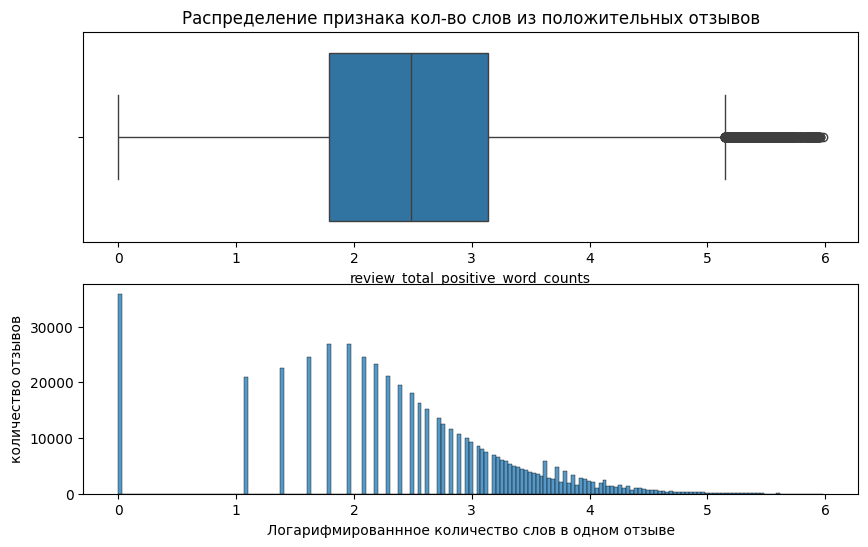

In [63]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

boxplot = sns.boxplot(data=hotels, x='review_total_positive_word_counts', ax=axes[0]);
boxplot.set_title('Распределение признака кол-во слов из положительных отзывов');

histplot = sns.histplot(data=hotels, x='review_total_positive_word_counts', ax=axes[1]);

axes[1].set(
    xlabel='Логарифмированнное количество слов в одном отзыве', 
    ylabel='количество отзывов'
    )

plt.show()

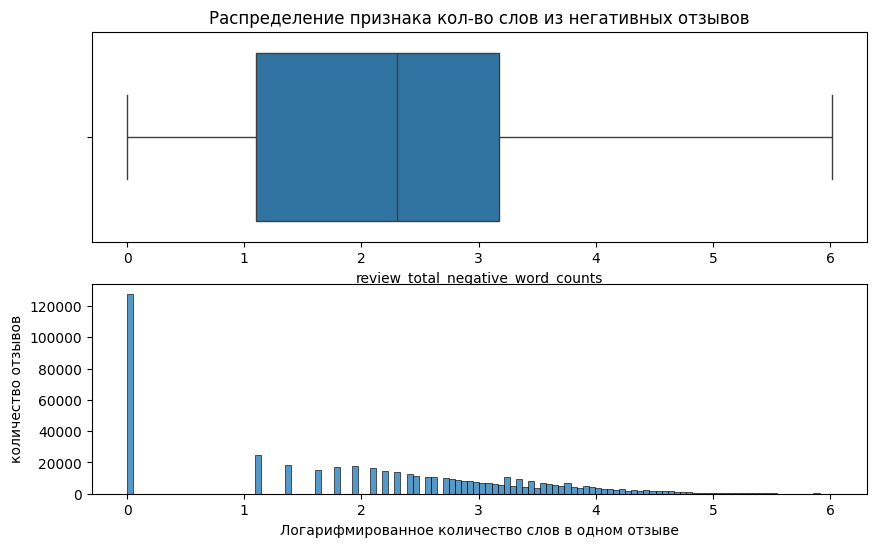

In [64]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

boxplot = sns.boxplot(data=hotels, x='review_total_negative_word_counts', ax=axes[0]);
boxplot.set_title('Распределение признака кол-во слов из негативных отзывов');

histplot = sns.histplot(data=hotels, x='review_total_negative_word_counts', ax=axes[1]);
# histplot.set_title('Cleaned Full Square Distribution');
axes[1].set(
    xlabel='Логарифмированное количество слов в одном отзыве', 
    ylabel='количество отзывов'
    )

plt.show()

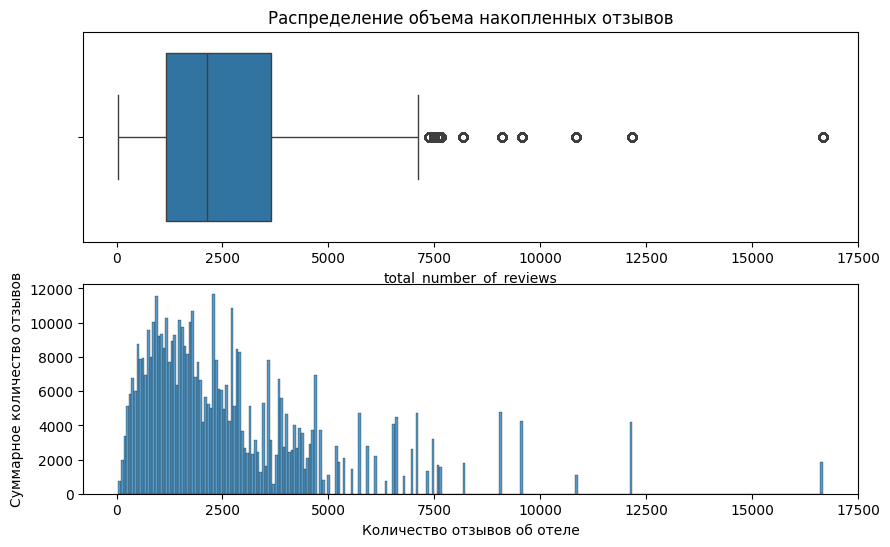

In [65]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

boxplot = sns.boxplot(data=hotels, x='total_number_of_reviews', ax=axes[0]);
boxplot.set_title('Распределение объема накопленных отзывов');

histplot = sns.histplot(data=hotels, x='total_number_of_reviews', ax=axes[1]);

axes[1].set(
    xlabel='Количество отзывов об отеле', 
    ylabel='Суммарное количество отзывов'
    )

plt.show()

In [66]:
mask = hotels['total_number_of_reviews'] > 11000
over_limit = hotels[mask].shape[0]
print(over_limit)
limit = 11000
hotels['total_number_of_reviews'] = (
    hotels['total_number_of_reviews'].apply(lambda x: x if x <= limit else limit))

6045


In [67]:
# Из-за большого разброса данных логарифмируем признак
hotels['total_number_of_reviews_reviewer_has_given'] = np.log1p(
    hotels['total_number_of_reviews_reviewer_has_given'])

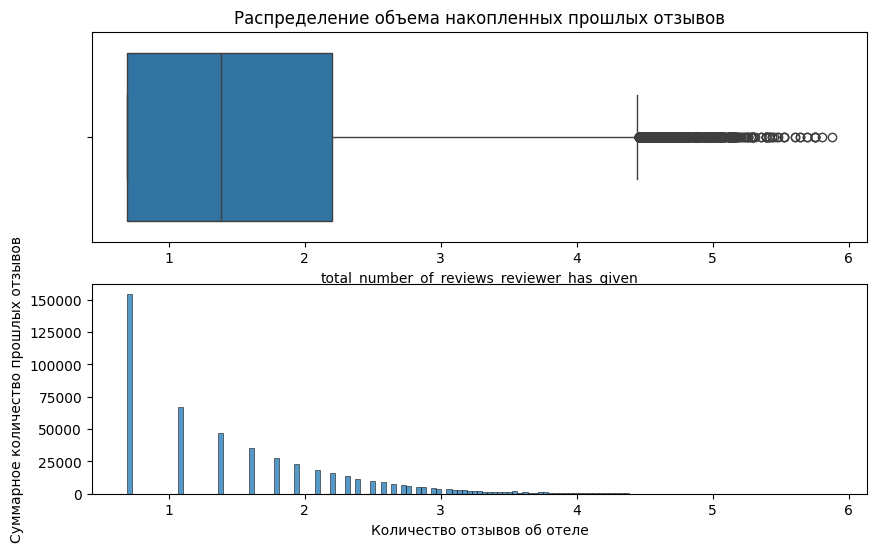

In [68]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

boxplot = sns.boxplot(
    data=hotels, x='total_number_of_reviews_reviewer_has_given', ax=axes[0]);
boxplot.set_title('Распределение объема накопленных прошлых отзывов');

histplot = sns.histplot(
    data=hotels, x='total_number_of_reviews_reviewer_has_given', ax=axes[1]);

axes[1].set(
    xlabel='Количество отзывов об отеле', 
    ylabel='Суммарное количество прошлых отзывов'
    )

plt.show()

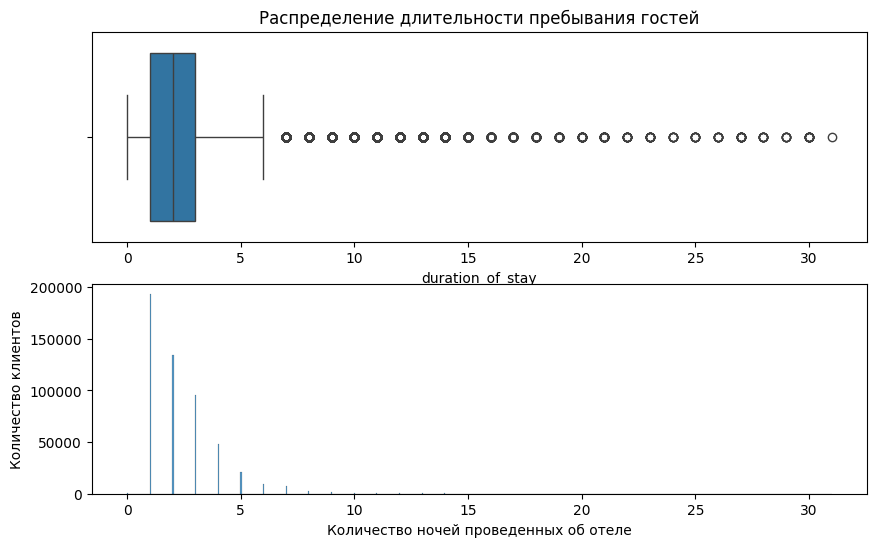

In [69]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

boxplot = sns.boxplot(data=hotels, x='duration_of_stay', ax=axes[0]);
boxplot.set_title('Распределение длительности пребывания гостей');

histplot = sns.histplot(data=hotels, x='duration_of_stay', ax=axes[1]);

axes[1].set(
    xlabel='Количество ночей проведенных об отеле', 
    ylabel='Количество клиентов'
    )

plt.show()

In [70]:
mask = hotels['duration_of_stay'] > 14
over_limit = hotels[mask].shape[0]
print(over_limit)

hotels['duration_of_stay'] = hotels['duration_of_stay'].clip(upper=14)

395


#### Проведем корреляционный анализ

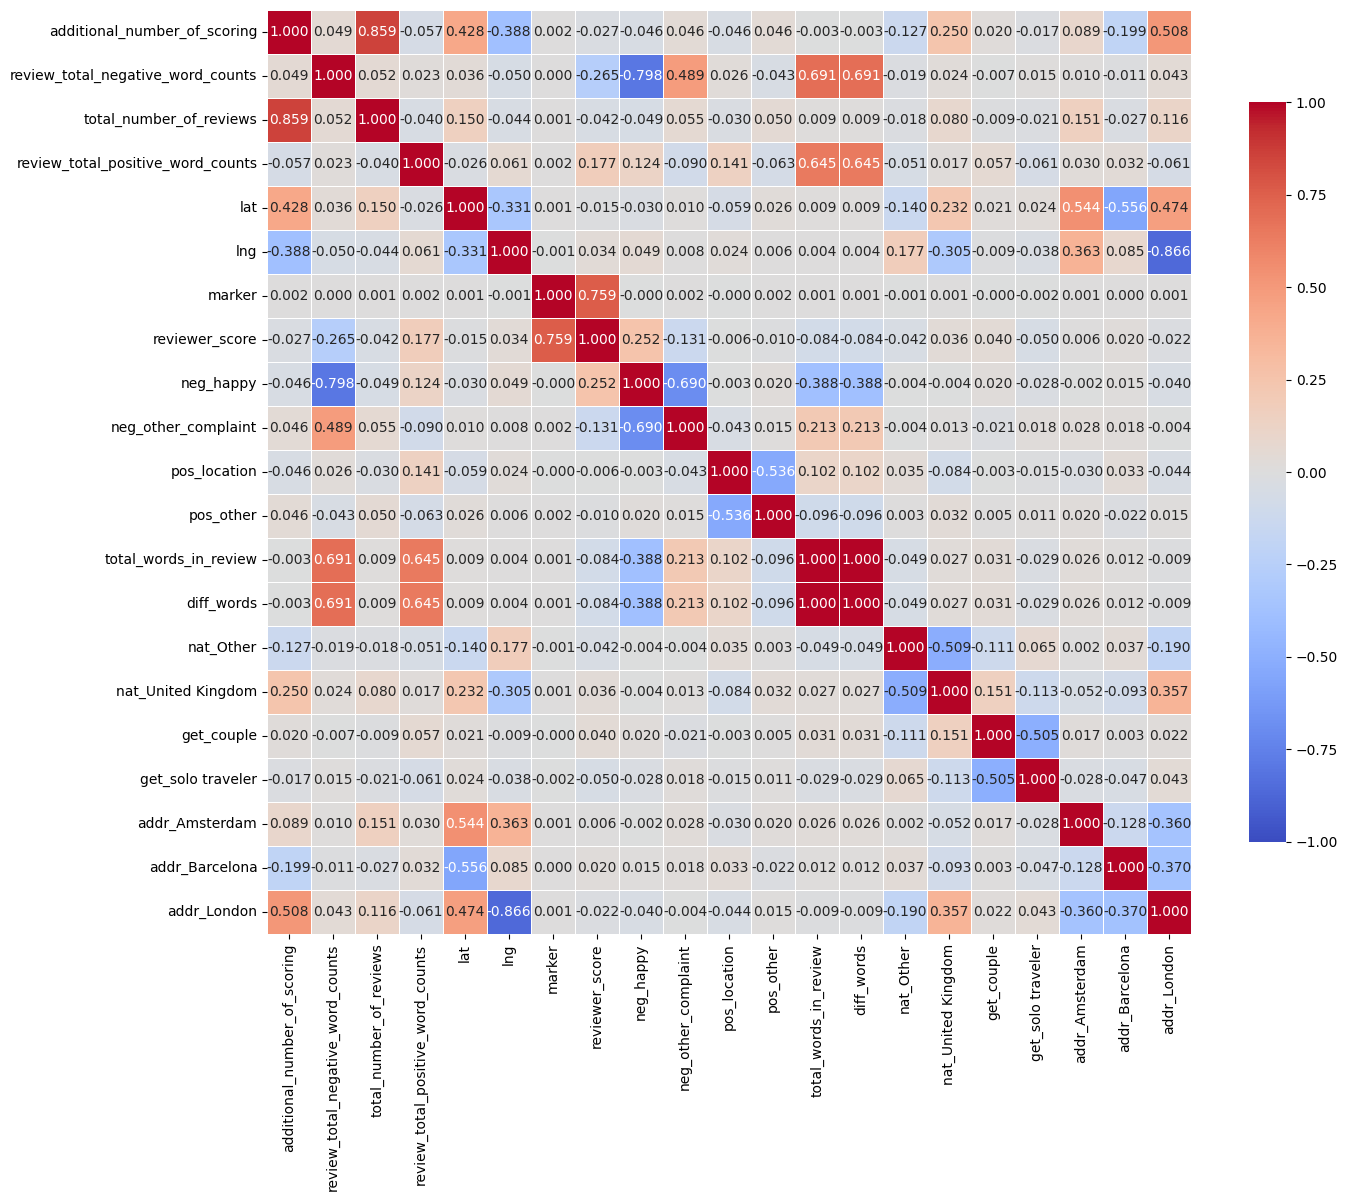

In [71]:
# 1. Считаем корреляцию
corr = hotels.corr(numeric_only=True, method='spearman') 

# 2. Создаем маску
strong_filter = (abs(corr) > 0.5) & (abs(corr) < 1.0)

# 3. Формируем список (один раз!)
cols_to_keep = corr.columns[strong_filter.any()].tolist()

# 4. Добавляем таргет, если его там нет
target_col = 'reviewer_score'
if target_col not in cols_to_keep:
    cols_to_keep.append(target_col)

# 5. Обрезаем матрицу (используем уже готовый cols_to_keep)
filtered_corr = corr.loc[cols_to_keep, cols_to_keep]

# 4. Строим карту (теперь она будет намного крупнее, так как колонок меньше)
plt.figure(figsize=(15, 12))
sns.heatmap(
    filtered_corr, 
    annot=True, 
    cmap='coolwarm',
    linewidths=0.5, 
    fmt=".3f", 
    vmin=-1, vmax=1,
    square=True, # Делает ячейки идеально квадратными
    cbar_kws={"shrink": .8}
)
plt.show()

#### Коэффициент корреляции превышает допустимые границы у трех пар признаков, это: 
* пара 'additional_number_of_scoring' и 'total_number_of_reviews';
* пара 'addr_London' и 'lng';
* пара 'diff_words' и 'total_words_in_review' 
Из этих трех пар я оставлю более важные и информативные признаки. Три признаки которые я считаю менее важными я удалю

In [72]:
# Удаление менее важных признаков у которых высокий коэф. корреляции
hotels = hotels.drop(
    ['additional_number_of_scoring', 'addr_London', 'total_words_in_review'], axis=1)

#### Переходим к подготовке модели к обучению

In [73]:
# Непрерывные признаки
num_cols = [
    'average_score', 'review_total_negative_word_counts', 'lat', 'lng',
    'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given',
    'dist_center', 'days_since_review', 'diff_words', 'total_number_of_reviews'
    ]

# Категориальные признаки: 
cat_cols = [
    'neg_breakfast', 'neg_happy', 'neg_other_complaint', 'neg_small_room', 
    'dis_positive','is_positive', 'pos_displeased', 'pos_location', 'pos_other', 
    'pos_perfect', 'pos_staff', 'trip_purpose', 'is_mobile', 'duration_of_stay',
    'month_date', 'day_date', 'addr_Milan', 'addr_Paris', 'nat_Australia', 
    'nat_Netherlands', 'nat_France', 'nat_Germany', 'nat_Ireland', 'nat_Switzerland', 
    'nat_Other', 'nat_Saudi Arabia', 'nat_Turkey', 'nat_United Arab Emirates', 
    'nat_United Kingdom', 'nat_United States of America', 'get_couple',
    'get_family with older children', 'get_family with young children',
    'get_group', 'get_solo traveler', 'amount_word', 'lux_weight' 
    ]

#### Готовимся к валидации.

In [74]:
train_df = hotels[hotels['marker'] == 1].drop(['marker'], axis=1) 
X_submission = hotels[hotels['marker'] == 0].drop(['marker', 'reviewer_score'], axis=1)

In [75]:
# Выделяем целевую переменную y
yv = train_df['reviewer_score']

XV = train_df.drop('reviewer_score', axis=1)

amount_word                          31.502450
nat_Ireland                          56.925737
day_date                             64.240050
get_family with older children       85.298643
addr_Paris                           87.561657
addr_Milan                           95.046373
get_group                            97.835647
nat_France                          144.360755
pos_other                           158.136471
get_family with young children      186.371642
nat_Australia                       229.528422
nat_Germany                         253.252129
nat_Turkey                          276.958997
nat_Switzerland                     326.954165
nat_Netherlands                     367.630871
duration_of_stay                    432.264500
trip_purpose                        484.086691
is_mobile                           624.603036
lux_weight                          647.993993
nat_Saudi Arabia                    665.209885
month_date                          731.116137
nat_United Ar

<Axes: >

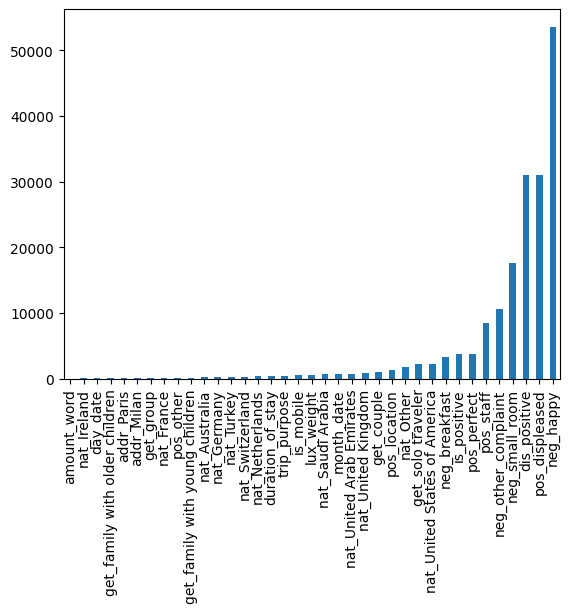

In [76]:
yv_0 = yv.astype('int')

from sklearn.feature_selection import chi2

imp_cat = pd.Series(chi2(XV[cat_cols], yv_0)[0], index = cat_cols)
imp_cat.sort_values(inplace = True)
display(imp_cat)
imp_cat.plot(kind='bar')


days_since_review                                26.722059
lat                                              75.584346
lng                                              92.426175
dist_center                                     186.525671
total_number_of_reviews                         292.574747
total_number_of_reviews_reviewer_has_given      401.009049
diff_words                                     1519.850769
review_total_positive_word_counts              6690.361842
average_score                                  7588.683414
review_total_negative_word_counts             13920.291102
dtype: float64

<Axes: >

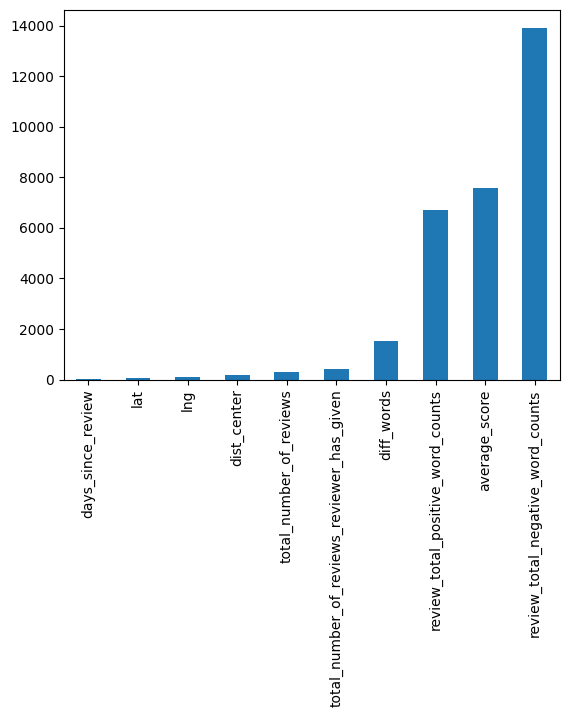

In [77]:
from sklearn.feature_selection import f_classif 

imp_num = pd.Series(f_classif(XV[num_cols], yv_0)[0], index = num_cols)
imp_num.sort_values(inplace=True)
display(imp_num)
imp_num.plot(kind = 'bar')

#### По результатам тестов chi2 и f_classif можно выделить малозначимые признаки, которые следует удалить. Удалять я буду следующие признаки: 
* 'get_Unknown';
* 'nat_Ireland';

In [78]:
# Список признаков который будем удалять из XV
list_drop = [
    'get_Unknown', 'addr_Vienna', 'addr_Amsterdam', 'addr_Barcelona', 
    'nat_Belgium', 'nat_Canada', 'nat_Israel', 'nat_Italy'
    ]

In [79]:
XV = XV.drop(list_drop, axis=1)

In [80]:
# Загружаем специальный инструмент для разбивки:  
from sklearn.model_selection import train_test_split  

In [81]:
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.  
# Для тестирования мы будем использовать 25% от исходного датасета.  
XV_train, XV_test, yv_train, yv_test = train_test_split(XV, yv, test_size=0.25, random_state=42)

In [82]:
# Импортируем необходимые библиотеки:  
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
  
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(XV_train, yv_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную yv_pred  
yv_pred = regr.predict(XV_test)  


### Добавим еще один график "feature_importances_". Этот график покажет как модель распределяет признаки в зависимости от их важности влияния на результат. 

nat_Switzerland                               0.001530
nat_Turkey                                    0.001530
nat_Netherlands                               0.001532
nat_Germany                                   0.001620
nat_France                                    0.001695
addr_Milan                                    0.001745
pos_perfect                                   0.001843
is_positive                                   0.001854
nat_Ireland                                   0.002062
nat_Australia                                 0.002284
addr_Paris                                    0.002301
nat_Saudi Arabia                              0.002614
neg_breakfast                                 0.002842
get_family with older children                0.003012
nat_United Arab Emirates                      0.003175
neg_other_complaint                           0.003240
nat_United States of America                  0.003754
dis_positive                                  0.003793
pos_disple

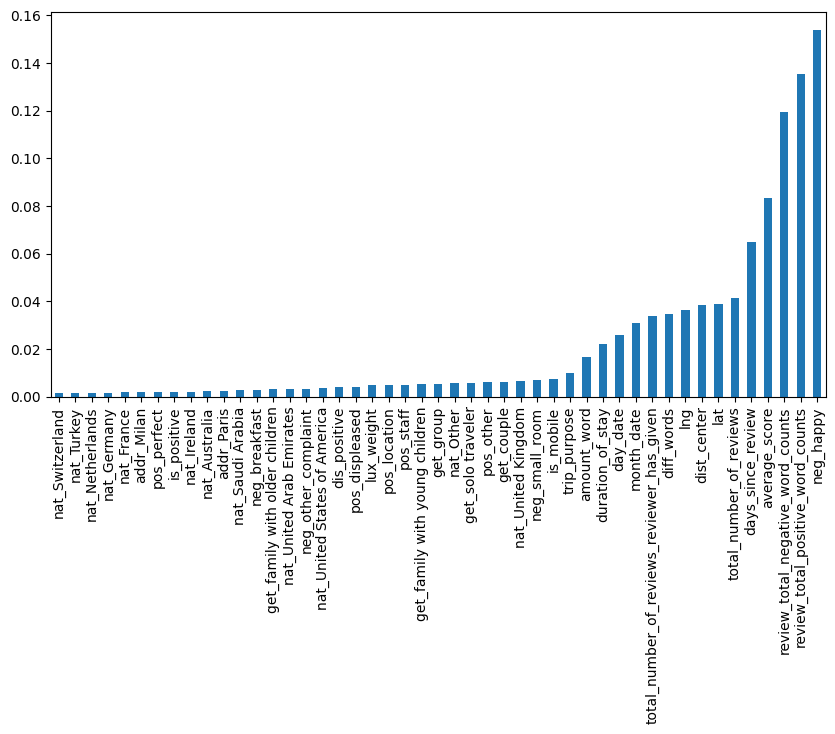

In [83]:
# Смотрим, какие признаки модель считает самыми важными
plt.figure(figsize=(10,5))
importances = pd.Series(regr.feature_importances_, index=XV.columns)
importances.sort_values().plot(kind='bar')
display(importances.sort_values())

In [84]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.  
print('MAPE:', metrics.mean_absolute_percentage_error(yv_test, yv_pred))

MAPE: 0.13158638182097526


In [85]:
X_submission = X_submission.drop(list_drop, axis=1)

In [86]:
# Делаем предсказание (используем обученную модель regr)
y_submission = regr.predict(X_submission)

# Используем уже загруженный sample_submission
pred_submission['reviewer_score'] = y_submission

# Сохраняем результат
pred_submission.to_csv('submission.csv', index=False)

print(f'Submission.csv file created successfully!')

Submission.csv file created successfully!
